In [1]:
from supermarket import Grid
from shopping_list import ShoppingList
import distance as distance

grid = Grid("supermarket-grids/grid_eng.txt")
shopping_list = ShoppingList.load_from_file("shopping-lists/long_shopping_list.txt")
J_product_category, P_product_category, product_type_indizes = distance.compute_optimal_trajectories(grid, (5,4), (5,0))
J_product, P_product = distance.create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)

# Introducing hardness

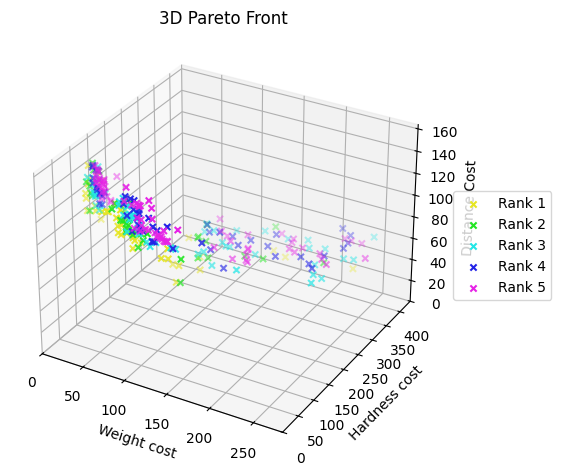

In [2]:
import weight
import hardness
import distance
import evolution_3d

m = 1000
weight_costs, hardness_costs, distance_costs = [], [], []
for i in range(m):
    if i < m/3:
        order = weight.generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
    elif i < 2/3*m:
        order = hardness.generate_hardness_greedy_order(shopping_list, alpha=0.5)
    else:
        order = distance.generate_distancegreedy_random_order(J_product, alpha = 0.5)

    weight_cost = weight.compute_weight_cost(order, shopping_list)
    weight_costs.append(weight_cost)
    hardness_cost = hardness.compute_hardness_cost(order, shopping_list)
    hardness_costs.append(hardness_cost)
    distance_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
    distance_costs.append(distance_cost)
import matplotlib.pyplot as plt
final_ranking, ranks, crowding_distances = evolution_3d.pareto_rank_3_with_crowding(weight_costs, hardness_costs, distance_costs)
evolution_3d.plot_pareto_3(ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel = "Distance Cost", max_legend_ranks=6, plot_high_ranks=False)


# 3D Evolution

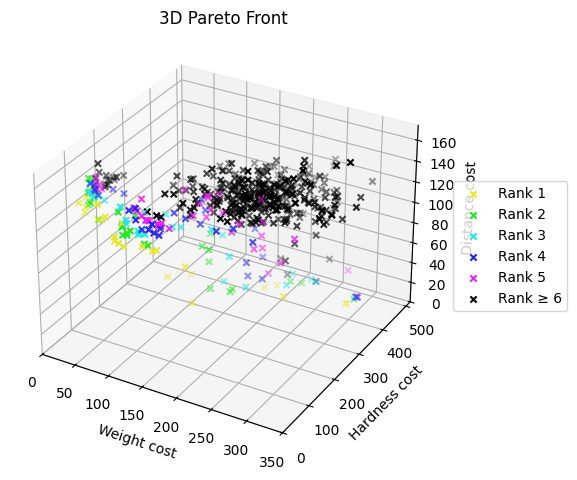

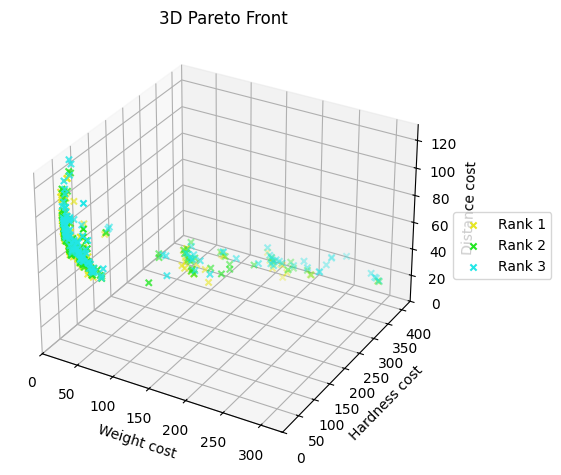

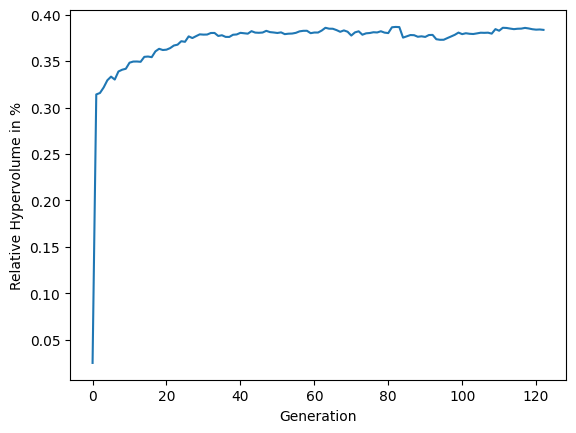

In [3]:
import evolution_3d
import hypervolume as hv

reference_point = (200, 400, 500)
population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs, hypervolume_list, reference_point = evolution_3d.evolution_3d(
            shopping_list, J_product, patience=10, generation_size=100, population_size=500, reference_point=reference_point)
evolution_3d.plot_pareto_3(pareto_ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel="Distance cost", max_legend_ranks=6, plot_high_ranks=True, reference_point=None, saving_path = "pareto_front_3d.jpg")
hv.plot_hypervolume(hypervolume_list, saving_path="hypervolume_3d.jpg")


ORDER COSTS: Distance = 56 (0.36) | Weight = 54 (0.17) | Hardness = 45 (0.09)
['Water', 'Orange Juice', 'Spezi', 'Beer', 'Lasagna', 'Tabasco', 'Frozen Burritos', 'Pizza', 'Sausage', 'Salmon', 'Tuna', 'Mozzarella', 'Cheddar', 'Chicken Breast', 'Cashews', 'Almonds', 'Soy Milk', 'Carrot', 'Banana', 'Flowers', 'Apple', 'Broccoli', 'Toiletpaper', 'Cracker', 'Chocolate', 'Baguette', 'Croissant']
Weights in order:                   [4, 3, 3, 5, 3, 1, 3, 3, 3, 3, 3, 2, 2, 3, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 2, 1]
Hardness in order:                  [5, 5, 5, 5, 4, 5, 4, 4, 4, 3, 5, 2, 3, 2, 4, 4, 3, 3, 1, 1, 2, 2, 1, 2, 3, 2, 1]
Distance between products:          [4, 1, 1, 1, 6, 4, 3, 1, 5, 1, 1, 1, 0, 1, 3, 0, 3, 2, 1, 1, 1, 1, 4, 1, 1, 4, 0, 4]
Mean path length between each step: 2.0


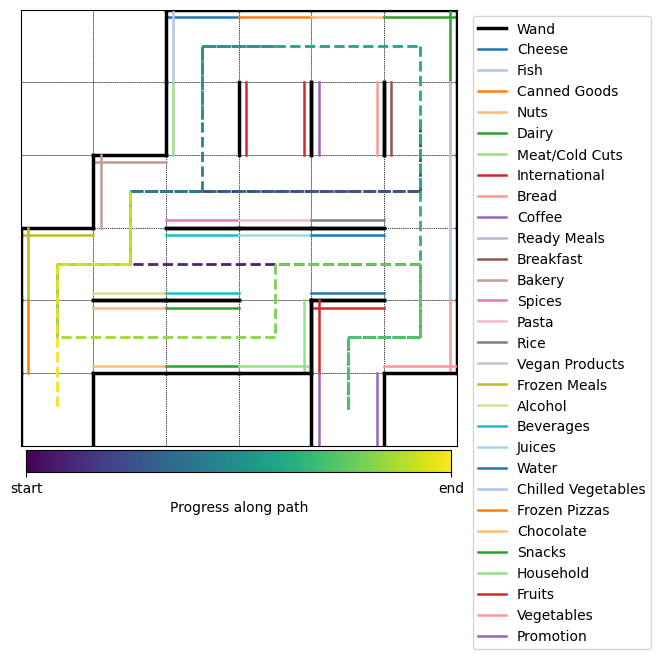

In [4]:
import decision_making
weights = [0.6, 0.3, 0.1] # Distance, Weight, Hardness
decision_making.summarize_results(population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs, weights, P_product, grid, shopping_list)